In [55]:
!pip install lightgbm xgboost

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb

In [57]:
df = pd.read_csv("/Traffic (1).csv")
df

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal
...,...,...,...,...,...,...,...,...,...
2971,10:45:00 PM,9,Thursday,16,3,1,36,56,normal
2972,11:00:00 PM,9,Thursday,11,0,1,30,42,normal
2973,11:15:00 PM,9,Thursday,15,4,1,25,45,normal
2974,11:30:00 PM,9,Thursday,16,5,0,27,48,normal


In [58]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,12:00:00 AM,10,Tuesday,31,0,4,4,39,low
1,12:15:00 AM,10,Tuesday,49,0,3,3,55,low
2,12:30:00 AM,10,Tuesday,46,0,3,6,55,low
3,12:45:00 AM,10,Tuesday,51,0,2,5,58,low
4,1:00:00 AM,10,Tuesday,57,6,15,16,94,normal


In [59]:
df.shape

(2976, 9)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB


In [61]:
df.isnull().sum()

,0
Time,0
Date,0
Day of the week,0
CarCount,0
BikeCount,0
BusCount,0
TruckCount,0
Total,0
Traffic Situation,0


In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df = df.drop_duplicates()

In [64]:
df.shape

(2976, 9)

In [65]:
df["Traffic Situation"].value_counts()

,count
Traffic Situation,
normal,1669
heavy,682
high,321
low,304


In [66]:
df.dtypes

,0
Time,object
Date,int64
Day of the week,object
CarCount,int64
BikeCount,int64
BusCount,int64
TruckCount,int64
Total,int64
Traffic Situation,object


In [67]:
df.describe()

,Date,CarCount,BikeCount,BusCount,TruckCount,Total
count,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000,2976.000000
mean,16.000000,68.696573,14.917339,15.279570,15.324933,114.218414
std,8.945775,45.850693,12.847518,14.341986,10.603833,60.190627
min,1.000000,6.000000,0.000000,0.000000,0.000000,21.000000
25%,8.000000,19.000000,5.000000,1.000000,6.000000,55.000000
50%,16.000000,64.000000,12.000000,12.000000,14.000000,109.000000
75%,24.000000,107.000000,22.000000,25.000000,23.000000,164.000000
max,31.000000,180.000000,70.000000,50.000000,40.000000,279.000000


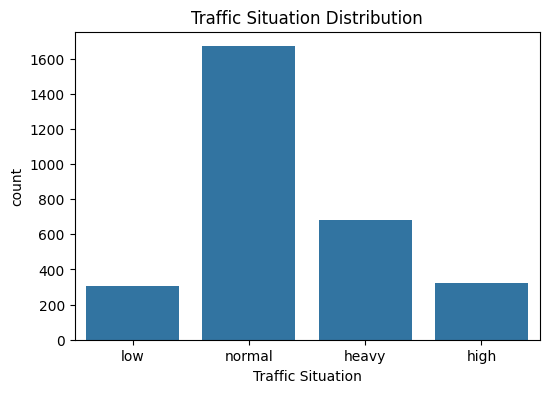

In [68]:
plt.figure(figsize=(6,4))
sns.countplot(x="Traffic Situation", data=df)
plt.title("Traffic Situation Distribution")
plt.show()

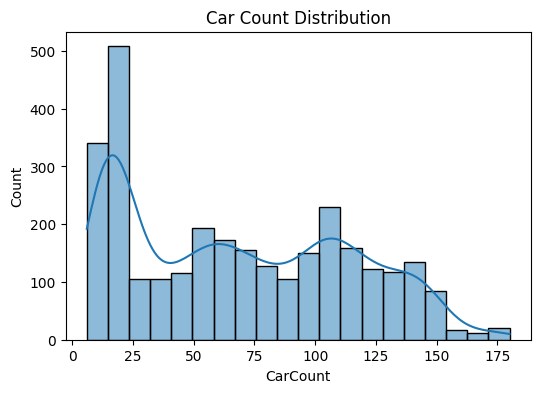

In [69]:
plt.figure(figsize=(6,4))
sns.histplot(df["CarCount"], bins=20, kde=True)
plt.title("Car Count Distribution")
plt.show()

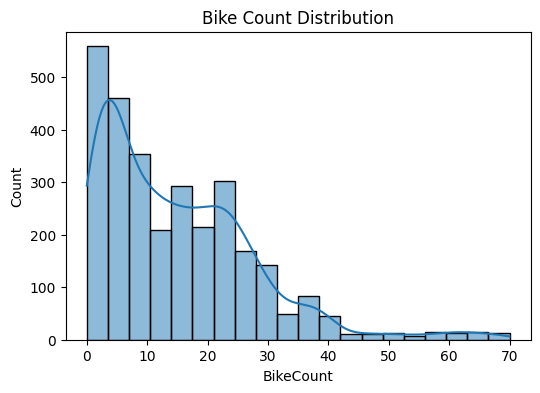

In [70]:
plt.figure(figsize=(6,4))
sns.histplot(df["BikeCount"], bins=20, kde=True)
plt.title("Bike Count Distribution")
plt.show()

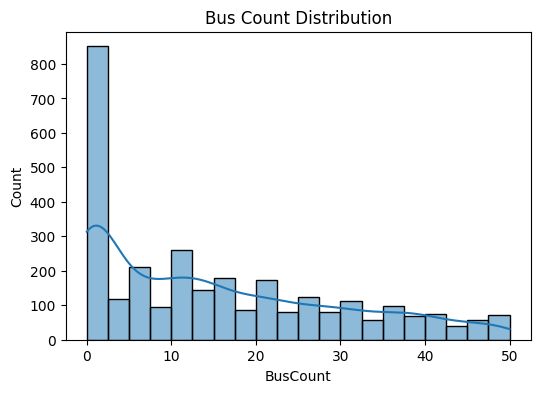

In [71]:
plt.figure(figsize=(6,4))
sns.histplot(df["BusCount"], bins=20, kde=True)
plt.title("Bus Count Distribution")
plt.show()

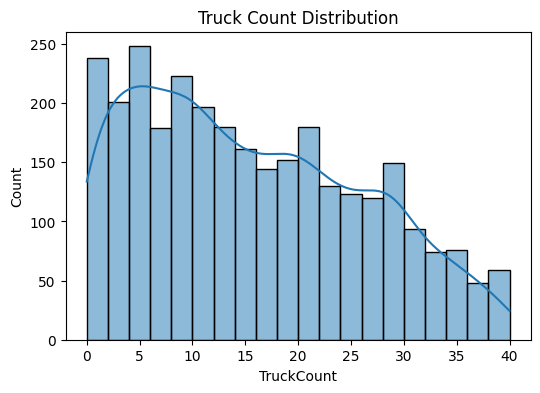

In [72]:
plt.figure(figsize=(6,4))
sns.histplot(df["TruckCount"], bins=20, kde=True)
plt.title("Truck Count Distribution")
plt.show()

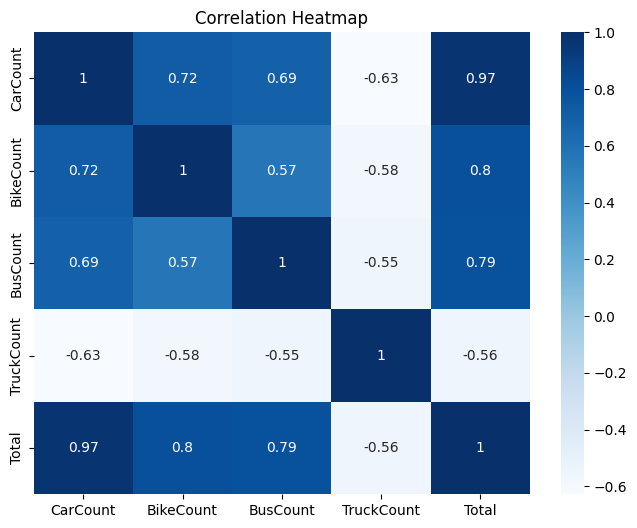

In [73]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["CarCount","BikeCount","BusCount","TruckCount","Total"]].corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

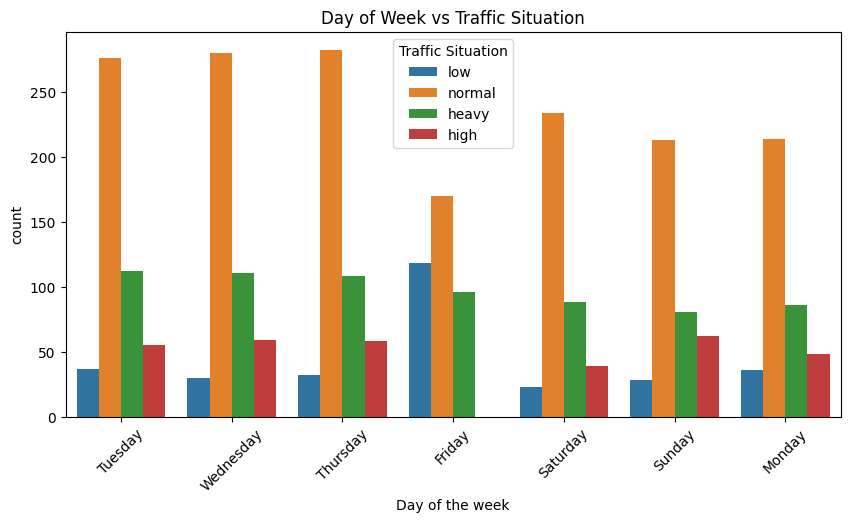

In [74]:
plt.figure(figsize=(10,5))
sns.countplot(x="Day of the week", hue="Traffic Situation", data=df)
plt.xticks(rotation=45)
plt.title("Day of Week vs Traffic Situation")
plt.show()

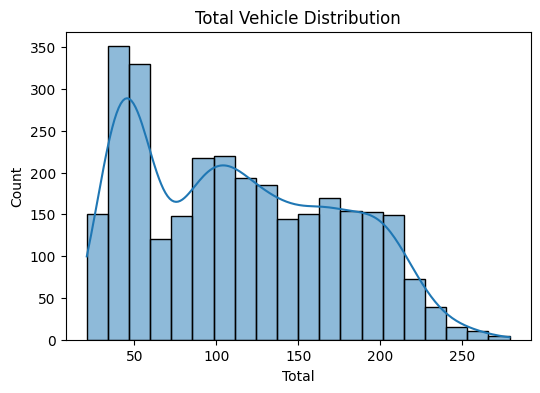

In [75]:
plt.figure(figsize=(6,4))
sns.histplot(df["Total"], bins=20, kde=True)
plt.title("Total Vehicle Distribution")
plt.show()

In [76]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/tmp/ipykernel_942/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


In [77]:
df[["Time","Hour"]].head()

,Time,Hour
0,12:00:00 AM,0
1,12:15:00 AM,0
2,12:30:00 AM,0
3,12:45:00 AM,0
4,1:00:00 AM,1


In [78]:
from sklearn.preprocessing import LabelEncoder

day_encoder = LabelEncoder()

df["Day of the week"] = day_encoder.fit_transform(df["Day of the week"])

In [79]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,12:00:00 AM,10,5,31,0,4,4,39,low,0
1,12:15:00 AM,10,5,49,0,3,3,55,low,0
2,12:30:00 AM,10,5,46,0,3,6,55,low,0
3,12:45:00 AM,10,5,51,0,2,5,58,low,0
4,1:00:00 AM,10,5,57,6,15,16,94,normal,1


In [80]:
traffic_encoder = LabelEncoder()

df["Traffic Situation"] = traffic_encoder.fit_transform(df["Traffic Situation"])

In [81]:
df.head()

,Time,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,Hour
0,12:00:00 AM,10,5,31,0,4,4,39,2,0
1,12:15:00 AM,10,5,49,0,3,3,55,2,0
2,12:30:00 AM,10,5,46,0,3,6,55,2,0
3,12:45:00 AM,10,5,51,0,2,5,58,2,0
4,1:00:00 AM,10,5,57,6,15,16,94,3,1


In [82]:
print(day_encoder.classes_)
print(traffic_encoder.classes_)

['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']
['heavy' 'high' 'low' 'normal']


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   int64 
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   int64 
 9   Hour               2976 non-null   int32 
dtypes: int32(1), int64(8), object(1)
memory usage: 221.0+ KB


In [84]:
X = df.drop("Traffic Situation", axis=1)

y = df["Traffic Situation"]

In [85]:
X = X.drop("Time", axis=1)

In [86]:
X.head()

,Date,Day of the week,CarCount,BikeCount,BusCount,TruckCount,Total,Hour
0,10,5,31,0,4,4,39,0
1,10,5,49,0,3,3,55,0
2,10,5,46,0,3,6,55,0
3,10,5,51,0,2,5,58,0
4,10,5,57,6,15,16,94,1


In [87]:
y.head()

,Traffic Situation
0,2
1,2
2,2
3,2
4,3


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (2380, 8)
Testing Data  : (596, 8)


In [89]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:05:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [90]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(random_state=42)

lgb_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 592
[LightGBM] [Info] Number of data points in the train set: 2380, number of used features: 8
[LightGBM] [Info] Start training from score -1.455888
[LightGBM] [Info] Start training from score -2.221896
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -0.582674
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

LGBMClassifier(random_state=42)

In [91]:
xgb_pred = xgb_model.predict(X_test)

lgb_pred = lgb_model.predict(X_test)

In [92]:
from sklearn.metrics import accuracy_score, classification_report

print("XGBoost Accuracy :", accuracy_score(y_test, xgb_pred))
print("LightGBM Accuracy :", accuracy_score(y_test, lgb_pred))

XGBoost Accuracy : 1.0
LightGBM Accuracy : 1.0


In [93]:
print("XGBoost Report")
print(classification_report(y_test, xgb_pred))

print("\n=========================\n")

print("LightGBM Report")
print(classification_report(y_test, lgb_pred))

XGBoost Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00        63
           2       1.00      1.00      1.00        66
           3       1.00      1.00      1.00       340

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596



LightGBM Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       127
           1       1.00      1.00      1.00        63
           2       1.00      1.00      1.00        66
           3       1.00      1.00      1.00       340

    accuracy                           1.00       596
   macro avg       1.00      1.00      1.00       596
weighted avg       1.00      1.00      1.00       596



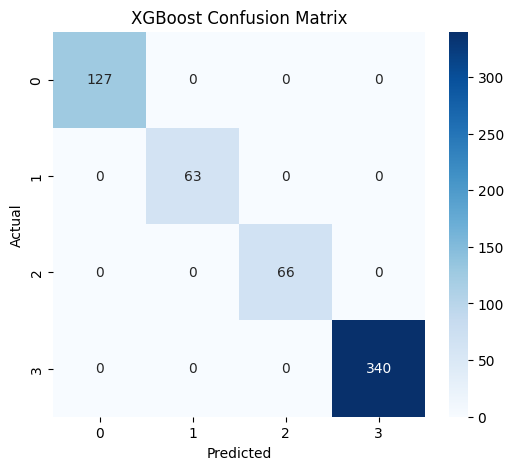

In [94]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
cm = confusion_matrix(y_test, lgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import joblib

joblib.dump(lgb_model, "traffic_model.pkl")
print("Model Saved Successfully!")